In [1]:
import os
import cv2
import torch
import pandas as pd
import xml.etree.ElementTree as ET

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision

In [2]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print(path)

100%|██████████| 398M/398M [00:11<00:00, 35.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


In [3]:
annotation_dir = os.path.join(path, "annotations")

records = []

for file in os.listdir(annotation_dir):

    tree = ET.parse(os.path.join(annotation_dir, file))
    root = tree.getroot()

    filename = root.find("filename").text

    for obj in root.findall("object"):

        label = obj.find("name").text
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        records.append([filename, label, xmin, ymin, xmax, ymax])

df = pd.DataFrame(
    records,
    columns=["image","label","xmin","ymin","xmax","ymax"]
)

df.head()

,image,label,xmin,ymin,xmax,ymax
0,maksssksksss7.png,with_mask,253,116,342,210
1,maksssksksss7.png,with_mask,152,96,222,174
2,maksssksksss7.png,with_mask,120,134,173,194
3,maksssksksss7.png,without_mask,118,66,135,90
4,maksssksksss545.png,with_mask,328,33,350,57


In [4]:
df.shape


(4072, 6)

In [5]:
df.columns

Index(['image', 'label', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')

In [6]:
df["label"].value_counts()

,count
label,
with_mask,3232
without_mask,717
mask_weared_incorrect,123


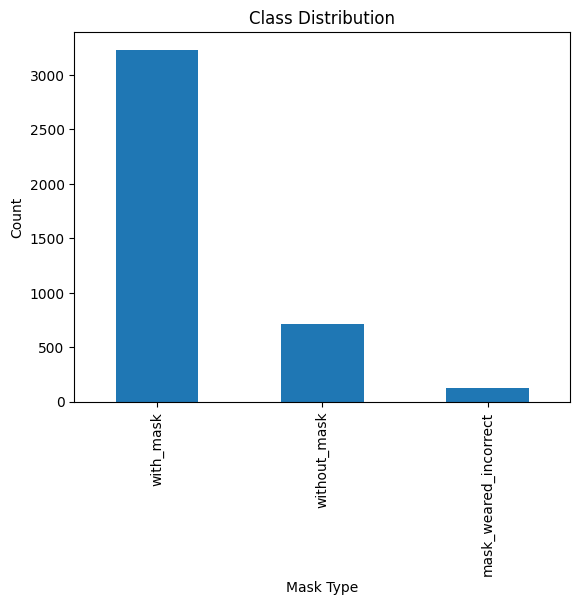

In [7]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Mask Type")
plt.ylabel("Count")
plt.show()

In [8]:
df["image"].nunique()

853

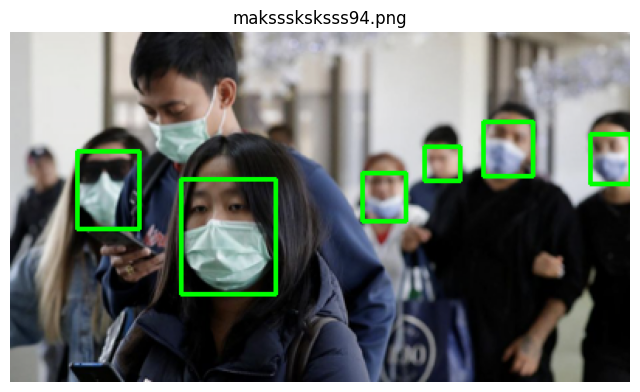

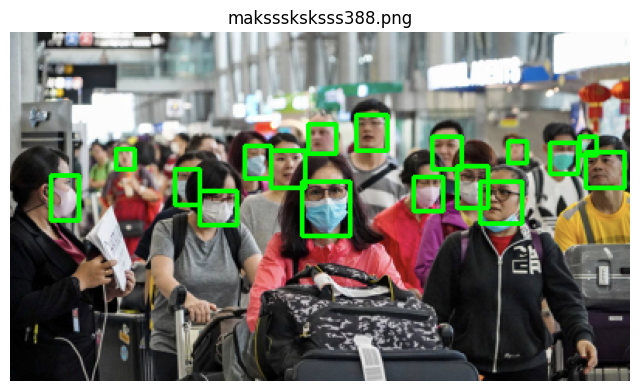

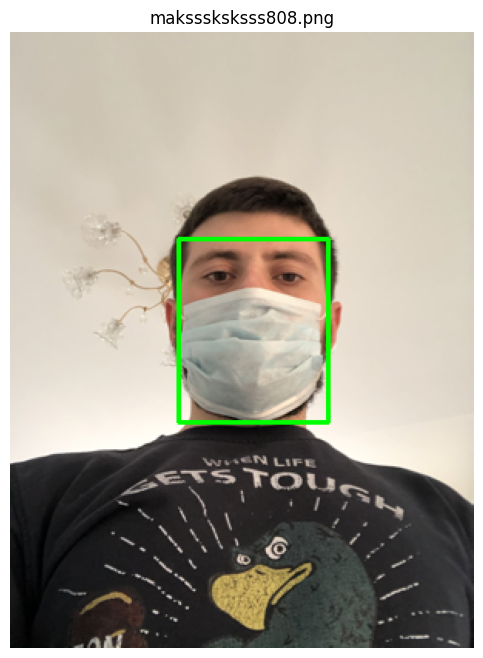

In [9]:
import random

image_dir = os.path.join(path, "images")

sample_images = random.sample(list(df["image"].unique()), 3)

for img_name in sample_images:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    rows = df[df["image" ] == img_name]

    for _, row in rows.iterrows():
        cv2.rectangle(
            img,
            (int(row["xmin"]), int(row["ymin"])),
            (int(row["xmax"]), int(row["ymax"])),
            (0, 255, 0),
            2
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [10]:
label_map = {
    "with_mask":1,
    "without_mask":2,
    "mask_weared_incorrect":3
}

df["label_id"] = df["label"].map(label_map)

In [11]:
#loc of img,loc of label ,load img
class MaskDataset(Dataset):

    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.images = df["image"].unique()
        self.transform = transform
#total num of image
    def __len__(self):
        return len(self.images)
#load one img
    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        #load image and convert into numpy arr
        img = cv2.imread(img_path)
        #bgr->rgb
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        records = self.df[self.df["image"] == img_name]

        boxes = records[["xmin","ymin","xmax","ymax"]].values
        labels = records["label_id"].values

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        if self.transform:
            img = self.transform(img)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

In [12]:
transform = transforms.Compose([
    #numpy->pil
    transforms.ToPILImage(),
    #convert to tensor
    transforms.ToTensor()
])

In [13]:
image_dir = os.path.join(path, "images")

dataset = MaskDataset(df, image_dir, transform)

In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [15]:
loader = DataLoader(
    dataset,
    num_workers=2,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

In [16]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True, min_size=512, max_size=512)

num_classes = 4

#get feature size
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 181MB/s]


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

Using device: cuda


In [18]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA Available: True
GPU Name: Tesla T4


In [19]:
import torch
torch.cuda.empty_cache()

In [20]:
import matplotlib.pyplot as plt

loss_history = []

model.train()

for epoch in range(20):

    epoch_loss = 0

    for imgs, targets in loader:
        #img move to gpu
        imgs = [img.to(device) for img in imgs]
        #label and box also
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]


        loss_dict = model(imgs, targets)

        #it return this classification_loss bbox_loss,rpn_loss,objectness_loss
        loss = sum(loss for loss in loss_dict.values())

        #old grad remove
        optimizer.zero_grad()

        #calculate the grad
        loss.backward()

        #update wait
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss = epoch_loss / len(loader)

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss}")

Epoch 1 | Loss: 0.5342312334018333
Epoch 2 | Loss: 0.3946479663218015
Epoch 3 | Loss: 0.3369394608677548
Epoch 4 | Loss: 0.29831012972047394
Epoch 5 | Loss: 0.2767479188705438
Epoch 6 | Loss: 0.2526347767561674
Epoch 7 | Loss: 0.22753009858114698
Epoch 8 | Loss: 0.2047121223044869
Epoch 9 | Loss: 0.20688752199862606
Epoch 10 | Loss: 0.1770243323799745
Epoch 11 | Loss: 0.17912696742356937
Epoch 12 | Loss: 0.16586457716875544
Epoch 13 | Loss: 0.1632783483087181
Epoch 14 | Loss: 0.1397259238515502
Epoch 15 | Loss: 0.1272711250843985
Epoch 16 | Loss: 0.1291342373658842
Epoch 17 | Loss: 0.12431476848356635
Epoch 18 | Loss: 0.13078235180299974
Epoch 19 | Loss: 0.1180373834202362
Epoch 20 | Loss: 0.14674456205184214


In [21]:
import torch
print(torch.cuda.is_available())

True


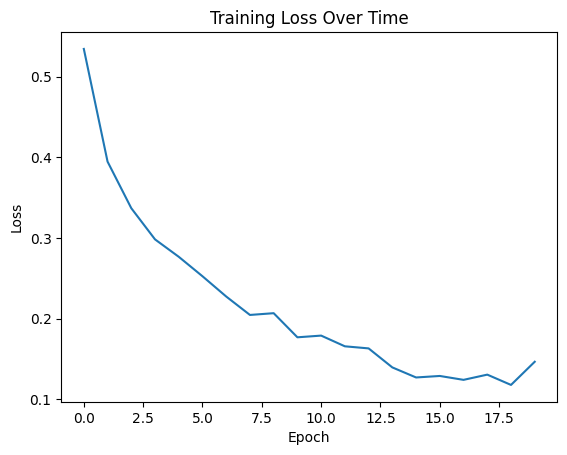

In [22]:
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [23]:
def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

In [36]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for imgs, targets in loader:

        imgs = [img.to(device) for img in imgs]

        preds = model(imgs)

        for pred, target in zip(preds, targets):

            gt_boxes = target["boxes"]
            gt_labels = target["labels"]

            pred_boxes = pred["boxes"].cpu()
            pred_labels = pred["labels"].cpu()
            pred_scores = pred["scores"].cpu()

            for pb, pl, ps in zip(pred_boxes, pred_labels, pred_scores):

                if ps < 0.5:
                    continue

                for gb, gl in zip(gt_boxes, gt_labels):

                    iou = calculate_iou(pb, gb)

                    if iou > 0.5:

                        total += 1

                        if pl == gl:
                            correct += 1

accuracy = correct / total if total > 0 else 0

print("Detection Accuracy:", accuracy)

Detection Accuracy: 0.9759603469640644


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

model.eval()

all_true = []
all_pred = []

with torch.no_grad():

    for imgs, targets in loader:

        imgs = [img.to(device) for img in imgs]

        preds = model(imgs)

        for pred, target in zip(preds, targets):

            gt_boxes = target["boxes"]
            gt_labels = target["labels"]

            pred_boxes = pred["boxes"].cpu()
            pred_labels = pred["labels"].cpu()
            pred_scores = pred["scores"].cpu()

            for pb, pl, ps in zip(pred_boxes, pred_labels, pred_scores):

                if ps < 0.5:
                    continue

                for gb, gl in zip(gt_boxes, gt_labels):

                    iou = calculate_iou(pb, gb)

                    if iou > 0.5:

                        all_true.append(gl.item())
                        all_pred.append(pl.item())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

In [34]:
accuracy = accuracy_score(all_true, all_pred)
precision = precision_score(all_true, all_pred, average="weighted")
recall = recall_score(all_true, all_pred, average="weighted")
f1 = f1_score(all_true, all_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9759543877045117
Precision: 0.976441742515746
Recall   : 0.9759543877045117
F1 Score : 0.9737131873860116


In [35]:
from sklearn.preprocessing import label_binarize

classes = [1, 2, 3]

true_bin = label_binarize(all_true, classes=classes)
pred_bin = label_binarize(all_pred, classes=classes)

roc_auc = roc_auc_score(true_bin, pred_bin, average="weighted", multi_class="ovr")

print("ROC AUC  :", roc_auc)

ROC AUC  : 0.9628309962921832


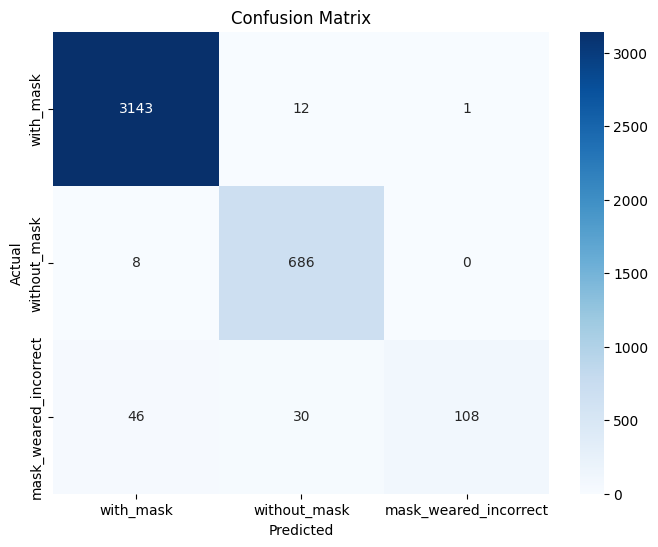

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_pred, labels=[1, 2, 3])

label_names = ["with_mask", "without_mask", "mask_weared_incorrect"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
torch.save(model.state_dict(), "mask_detector.pth")

In [30]:
from google.colab import files
files.download("mask_detector.pth")